# ECG Classification — Phase 1: Data Preparation

This notebook covers the full data preparation pipeline for the hierarchical ECG classifier.

**What this notebook does:**
- Loads raw ECG records and performs a clean record-level train/test split
- Bandpass filters and Z-score normalises every signal
- Slides windows across each signal (overlapping for train, non-overlapping for test)
- Augments only minority classes (A, O, ~) up to 2× their real count — Normal is never touched
- Generates 2-channel spectrograms (STFT + CWT) stored in memory-mapped files
- Aligns NeuroKit2 features to windows and scales them
- Saves all arrays to `ECG_Hierarchical/` so later phases can load them without rerunning this notebook

**Run this notebook once. All outputs are persisted to disk.**

## 1 · Imports and output directory

In [2]:
import os
import numpy as np
import pandas as pd
import pywt
import pickle
import scipy.signal
import scipy.ndimage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
from tqdm import tqdm

os.makedirs("ECG_Hierarchical", exist_ok=True)
print("Output directory ready.")

Output directory ready.


## 2 · Global constants

All hyperparameters that control windowing and spectrogram generation live here. Change them in one place.

In [3]:
FS          = 300
WINDOW_SIZE = 4500
STEP_TRAIN  = 2250
STEP_TEST   = 4500
SPEC_SIZE   = 128
LABEL_MAP   = {"N": 0, "A": 1, "O": 2, "~": 3}

## 3 · Load raw data

Expected format: a DataFrame with columns `record_id` (str), `label` (one of `N A O ~`), `signal` (array of floats at 300 Hz).

Adjust the loading cell below to match your actual file format.

In [5]:
meta    = pd.read_csv("ECG_Processed_Dataset/ecg_meta.csv")
signals = np.load("ECG_Processed_Dataset/ecg_signals.npy", allow_pickle=True)
meta["signal"] = signals
records_df     = meta.copy()

records_df["label_id"] = records_df["label"].map(LABEL_MAP)

records_df = records_df.dropna(subset=["label", "label_id"]).reset_index(drop=True)

print("Total records  :", len(records_df))
print("Label distribution:", Counter(records_df["label"]))
print("Sample signal length:", len(records_df["signal"].iloc[0]))

Total records  : 8528
Label distribution: Counter({'N': 5050, 'O': 2456, 'A': 738, '~': 284})
Sample signal length: 9000


## Step 1 · Record-level train/test split

**Why record-level?** If windows from the same record appear in both train and test, the model memorises patient-specific waveform patterns and reports inflated accuracy. Every window from a given record must stay on the same side of the split.

In [6]:
record_ids    = records_df["record_id"].values
record_labels = records_df["label_id"].values

train_ids, test_ids = train_test_split(
    record_ids,
    test_size    = 0.2,
    stratify     = record_labels,
    random_state = 42
)

train_df = records_df[records_df["record_id"].isin(train_ids)].reset_index(drop=True)
test_df  = records_df[records_df["record_id"].isin(test_ids)].reset_index(drop=True)

In [7]:
print("Train records:", len(train_df))
print("Test records :", len(test_df))
print("Train label distribution:", Counter(train_df["label"]))
print("Test label distribution :", Counter(test_df["label"]))

Train records: 6822
Test records : 1706
Train label distribution: Counter({'N': 4040, 'O': 1965, 'A': 590, '~': 227})
Test label distribution : Counter({'N': 1010, 'O': 491, 'A': 148, '~': 57})


## Step 2 · Bandpass filter and Z-score normalisation

**Bandpass 0.5–45 Hz** removes DC drift (below 0.5 Hz) and high-frequency noise and power-line artefacts (above 45 Hz).

**Z-score per signal** (not globally) ensures signals with very different amplitudes are comparable without leaking statistics between records.

In [8]:
def bandpass_filter(signal):
    b, a = scipy.signal.butter(2, [0.5 / 150, 45 / 150], btype="band")
    return scipy.signal.filtfilt(b, a, signal)

In [9]:
def z_score(signal):
    return (signal - signal.mean()) / (signal.std() + 1e-8)

In [10]:
def preprocess(signal):
    filtered = bandpass_filter(np.array(signal, dtype=np.float64))
    return z_score(filtered).astype(np.float32)

## Step 3 · Sliding window extraction

**Train:** 4500-sample windows (15 sec at 300 Hz) with 50% overlap → 2250-sample step. Overlap increases the number of training windows without changing the underlying data distribution.

**Test:** Non-overlapping windows (step = window size). No overlap at inference prevents the same beat from appearing in two test windows and inflating metrics.

`record_id` is stored with every window — required later to prevent leakage inside k-fold cross-validation.

In [11]:
def make_windows(signal, record_id, label, label_id, step):
    length  = len(signal)
    windows = []
    if length < WINDOW_SIZE:
        padded          = np.zeros(WINDOW_SIZE, dtype=np.float32)
        padded[:length] = signal
        windows.append((record_id, label, label_id, padded))
        return windows
    for start in range(0, length - WINDOW_SIZE + 1, step):
        win = signal[start : start + WINDOW_SIZE].copy()
        windows.append((record_id, label, label_id, win))
    return windows

In [12]:
def build_windowed_df(df, step):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Windowing"):
        sig = preprocess(row["signal"])
        rows.extend(make_windows(sig, row["record_id"], row["label"], row["label_id"], step))
    return pd.DataFrame(rows, columns=["record_id", "label", "label_id", "signal"])

In [13]:
train_windowed = build_windowed_df(train_df, STEP_TRAIN)
test_windowed  = build_windowed_df(test_df,  STEP_TEST)

print("Train windows:", len(train_windowed), dict(Counter(train_windowed["label"])))
print("Test windows :", len(test_windowed),  dict(Counter(test_windowed["label"])))

Windowing: 100%|██████████| 1706/1706 [00:03<00:00, 457.19it/s]

Train windows: 22360 {'N': 12996, 'A': 1955, 'O': 6923, '~': 486}
Test windows : 3573 {'N': 2093, 'O': 1090, '~': 96, 'A': 294}


## Step 4 · Augmentation — minority classes only, 2× cap

**What is augmented:** Only A (AFib), O (Other), and ~ (Noisy). Normal is left untouched — augmenting the majority class dilutes the decision boundary and caused Noisy F1 to collapse from 0.56 → 0.44 in earlier experiments.

**Augmentation techniques used:**
- Gaussian noise (σ = 0.05, p = 0.5)
- Amplitude scaling (uniform [0.9, 1.1], p = 0.5)
- Baseline wander (low-frequency sine at 0.1–0.5 Hz, amplitude 0.1, p = 0.5)

**Not used:** time shifting (displaces R-peaks), CutMix on Noisy (creates ambiguous labels).

**Target counts:** each minority class is augmented to exactly 2× its real window count.

In [14]:
def augment_one(signal):
    sig = signal.copy()
    if np.random.rand() < 0.5:
        sig = sig + np.random.normal(0, 0.05, size=sig.shape).astype(np.float32)
    if np.random.rand() < 0.5:
        sig = sig * np.random.uniform(0.9, 1.1)
    if np.random.rand() < 0.5:
        t      = np.arange(len(sig), dtype=np.float32) / FS
        freq   = np.random.uniform(0.1, 0.5)
        wander = (0.1 * np.sin(2 * np.pi * freq * t)).astype(np.float32)
        sig    = sig + wander
    return sig.astype(np.float32)

In [15]:
def augment_class_to_target(class_df, target_count):
    current  = len(class_df)
    if current >= target_count:
        return class_df.copy()
    needed   = target_count - current
    signals  = class_df["signal"].tolist()
    new_rows = []
    for i in range(needed):
        src_idx = i % len(signals)
        new_rows.append({
            "record_id": class_df.iloc[src_idx]["record_id"],
            "label":     class_df.iloc[src_idx]["label"],
            "label_id":  class_df.iloc[src_idx]["label_id"],
            "signal":    augment_one(signals[src_idx])
        })
    return pd.concat([class_df, pd.DataFrame(new_rows)], ignore_index=True)

In [16]:
real_counts = Counter(train_windowed["label"])
print("Real window counts:", dict(real_counts))

targets = {
    "N": real_counts["N"],
    "A": real_counts["A"] * 2,
    "O": real_counts["O"] * 2,
    "~": real_counts["~"] * 2,
}
print("Augmentation targets:", targets)

Real window counts: {'N': 12996, 'A': 1955, 'O': 6923, '~': 486}
Augmentation targets: {'N': 12996, 'A': 3910, 'O': 13846, '~': 972}


In [17]:
aug_parts = []
for label, target in targets.items():
    class_df  = train_windowed[train_windowed["label"] == label]
    aug_class = augment_class_to_target(class_df, target)
    aug_parts.append(aug_class)
    print(f"  {label}: {len(class_df)} real -> {len(aug_class)} after augmentation")

train_augmented = pd.concat(aug_parts, ignore_index=True)
train_augmented = train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)
print("Total augmented train windows:", len(train_augmented))
print("Distribution:", dict(Counter(train_augmented["label"])))

  N: 12996 real -> 12996 after augmentation
  A: 1955 real -> 3910 after augmentation
  O: 6923 real -> 13846 after augmentation
  ~: 486 real -> 972 after augmentation
Total augmented train windows: 31724
Distribution: {'O': 13846, 'N': 12996, 'A': 3910, '~': 972}


### Save augmented signals to a memory-mapped file

Memory maps let you read individual rows without loading the full array into RAM — important on Colab's 12 GB limit.

In [18]:
aug_sig_path = "ECG_Hierarchical/aug_signals.dat"
n_aug        = len(train_augmented)

aug_memmap = np.memmap(aug_sig_path, dtype="float32", mode="w+", shape=(n_aug, WINDOW_SIZE))
for i, sig in enumerate(tqdm(train_augmented["signal"], desc="Saving augmented signals to memmap")):
    aug_memmap[i] = sig
aug_memmap.flush()

print("Saved:", aug_sig_path, " shape:", aug_memmap.shape)

Saving augmented signals to memmap: 100%|██████████| 31724/31724 [00:00<00:00, 64323.06it/s]


Saved: ECG_Hierarchical/aug_signals.dat  shape: (31724, 4500)


## Step 5 · Spectrogram generation (STFT + CWT) → memory-mapped files

Two channels per window:

| Channel | Transform | Best at detecting |
|---------|-----------|-------------------|
| 0 | STFT (log magnitude) | Rhythm irregularity, Noisy signals |
| 1 | CWT (Morlet, scales 1–127) | Beat morphology, Other arrhythmias |

Each channel is independently min-max normalised to [0, 1] so neither dominates the other.

Output shape per sample: `(2, 128, 128)`.

**Stored as a memory-mapped `.dat` file** — not `.npy` — so the full spectrogram array is never loaded into RAM at once during training.

**This cell is the slowest in the notebook.** For ~9000 training windows it takes 15–25 minutes on Colab CPU. Run it once and never again — the `.dat` file persists across sessions.

In [19]:
def compute_stft_channel(signal):
    _, _, Zxx = scipy.signal.stft(signal, fs=FS, nperseg=64, noverlap=48)
    mag       = np.log1p(np.abs(Zxx)).astype(np.float32)
    h, w      = mag.shape
    resized   = scipy.ndimage.zoom(mag, (SPEC_SIZE / h, SPEC_SIZE / w), order=1)
    return resized.astype(np.float32)

In [20]:
def compute_cwt_channel(signal):
    scales    = np.arange(1, 128)
    coef, _   = pywt.cwt(signal.astype(np.float64), scales, "morl")
    mag       = np.abs(coef).astype(np.float32)
    h, w      = mag.shape
    resized   = scipy.ndimage.zoom(mag, (SPEC_SIZE / h, SPEC_SIZE / w), order=1)
    return resized.astype(np.float32)

In [21]:
def normalise_channel(ch):
    mn, mx = ch.min(), ch.max()
    if mx - mn < 1e-8:
        return np.zeros_like(ch)
    return ((ch - mn) / (mx - mn)).astype(np.float32)

In [22]:
def build_spectrogram(signal):
    stft_ch = normalise_channel(compute_stft_channel(signal))
    cwt_ch  = normalise_channel(compute_cwt_channel(signal))
    return np.stack([stft_ch, cwt_ch], axis=0)

### Generate train spectrograms

Flushes to disk every 500 windows so a Colab crash does not lose all progress. **If the session crashes mid-way, delete the `.dat` file and re-run — partial writes are not recoverable.**

In [23]:
train_spec_path = "ECG_Hierarchical/X_train_spec.dat"
n_train_aug     = len(train_augmented)

train_spec_mm = np.memmap(train_spec_path, dtype="float32", mode="w+",
                           shape=(n_train_aug, 2, SPEC_SIZE, SPEC_SIZE))

for i, sig in enumerate(tqdm(train_augmented["signal"], desc="Train spectrograms")):
    train_spec_mm[i] = build_spectrogram(np.array(sig, dtype=np.float32))
    if (i + 1) % 500 == 0:
        train_spec_mm.flush()
        print(f"  Flushed at {i+1}/{n_train_aug}")

train_spec_mm.flush()
print("Train spec memmap complete:", train_spec_path, "shape:", train_spec_mm.shape)

Train spectrograms:   2%|▏         | 500/31724 [01:30<1:36:59,  5.37it/s]

  Flushed at 500/31724


Train spectrograms:   3%|▎         | 1000/31724 [03:02<1:33:41,  5.46it/s]

  Flushed at 1000/31724


Train spectrograms:   5%|▍         | 1500/31724 [04:46<1:55:08,  4.37it/s]

...

  Flushed at 31000/31724


Train spectrograms:  99%|█████████▉| 31501/31724 [1:35:49<00:30,  7.39it/s]

  Flushed at 31500/31724


Train spectrograms: 100%|██████████| 31724/31724 [1:36:18<00:00,  5.49it/s]


Train spec memmap complete: ECG_Hierarchical/X_train_spec.dat shape: (31724, 2, 128, 128)


### Generate test spectrograms

In [24]:
test_spec_path = "ECG_Hierarchical/X_test_spec.dat"
n_test_w       = len(test_windowed)

test_spec_mm = np.memmap(test_spec_path, dtype="float32", mode="w+", shape=(n_test_w, 2, SPEC_SIZE, SPEC_SIZE))

for i, sig in enumerate(tqdm(test_windowed["signal"], desc="Test spectrograms")):
    test_spec_mm[i] = build_spectrogram(np.array(sig, dtype=np.float32))
    if (i + 1) % 500 == 0:
        test_spec_mm.flush()

test_spec_mm.flush()
print("Test spec memmap complete:", test_spec_path, "shape:", test_spec_mm.shape)

Test spectrograms: 100%|██████████| 3573/3573 [08:00<00:00,  7.44it/s]

Test spec memmap complete: ECG_Hierarchical/X_test_spec.dat shape: (3573, 2, 128, 128)


### Quick sanity-check: visualise one spectrogram per class

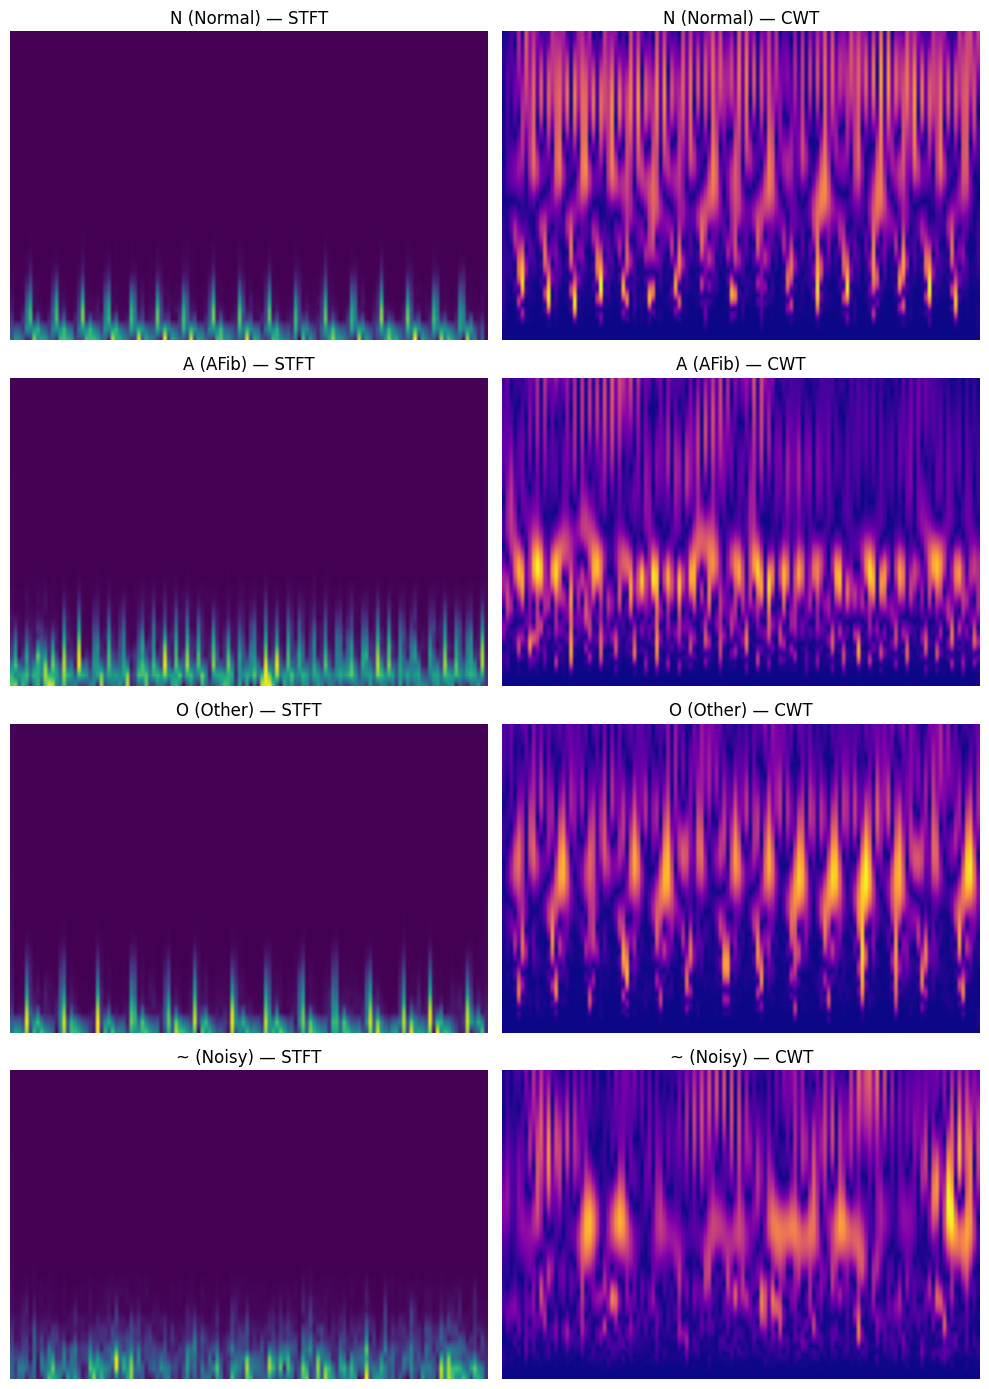

Spectrogram samples saved.


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
class_names = ["N (Normal)", "A (AFib)", "O (Other)", "~ (Noisy)"]

for row_idx, label_id in enumerate([0, 1, 2, 3]):
    idxs = np.where(train_augmented["label_id"].values == label_id)[0]
    if len(idxs) == 0:
        continue
    spec = train_spec_mm[idxs[0]]
    axes[row_idx, 0].imshow(spec[0], aspect="auto", origin="lower", cmap="viridis")
    axes[row_idx, 0].set_title(f"{class_names[label_id]} — STFT")
    axes[row_idx, 0].axis("off")
    axes[row_idx, 1].imshow(spec[1], aspect="auto", origin="lower", cmap="plasma")
    axes[row_idx, 1].set_title(f"{class_names[label_id]} — CWT")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.savefig("ECG_Hierarchical/spectrogram_samples.png", dpi=100)
plt.show()
print("Spectrogram samples saved.")

## Step 6 · NeuroKit2 feature alignment

Features in `ecg_features.csv` are extracted at the record level (one row per record). Every window from that record receives the same 35-feature vector — this is intentional. Rhythm-level features like RMSSD, pNN50, and SDNN are global properties of a record, not of a specific 15-second segment.

`StandardScaler` is fit on training windows only to prevent test information leaking into the scaler statistics.

In [26]:
features_df = pd.read_csv("ECG_Processed_Dataset/ecg_features.csv")
feat_cols   = [c for c in features_df.columns if c not in ["record_id", "label"]]

print("Feature columns:", len(feat_cols))
print(feat_cols)
print("Features DataFrame shape:", features_df.shape)

Feature columns: 39
['rr_mean', 'rr_std', 'rr_min', 'rr_max', 'rr_range', 'rr_cv', 'rr_median', 'rr_iqr', 'rr_skewness', 'rr_kurtosis', 'num_rpeaks', 'rmssd', 'sdsd', 'pnn50', 'pnn20', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_HTI', 'HRV_TINN', 'ecg_mean', 'ecg_std', 'ecg_skewness', 'ecg_kurtosis', 'ecg_energy', 'ecg_p2p', 'ecg_rms', 'r_amp_mean', 'r_amp_std', 'r_amp_cv']
Features DataFrame shape: (8519, 41)


In [27]:
def align_features(windowed_df, features_df, feat_cols):
    merged = windowed_df[["record_id"]].merge(
        features_df[["record_id"] + feat_cols],
        on="record_id", how="left"
    )
    arr = merged[feat_cols].fillna(0).values.astype(np.float32)
    return arr

In [28]:
X_train_feat_raw = align_features(train_augmented, features_df, feat_cols)
X_test_feat_raw  = align_features(test_windowed,   features_df, feat_cols)

print("Raw train features:", X_train_feat_raw.shape,
      "  NaN count:", np.isnan(X_train_feat_raw).sum())
print("Raw test features :", X_test_feat_raw.shape,
      "  NaN count:", np.isnan(X_test_feat_raw).sum())

Raw train features: (31724, 39)   NaN count: 0
Raw test features : (3573, 39)   NaN count: 0


In [29]:
scaler       = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat_raw).astype(np.float32)
X_test_feat  = scaler.transform(X_test_feat_raw).astype(np.float32)

print("Scaled train features:", X_train_feat.shape,
      "  mean:", X_train_feat.mean().round(4),
      "  std:", X_train_feat.std().round(4))
print("Scaled test features :", X_test_feat.shape)

with open("ECG_Hierarchical/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("ECG_Hierarchical/feat_cols.pkl", "wb") as f:
    pickle.dump(feat_cols, f)
print("Scaler and feat_cols saved.")

Scaled train features: (31724, 39)   mean: -0.0   std: 1.0
Scaled test features : (3573, 39)
Scaler and feat_cols saved.


## Step 7 · Build all arrays and save to disk

Signal arrays are stored as `.npy` (small enough to fit in RAM).
Spectrograms stay in `.dat` memory-mapped files (too large for RAM).
Label arrays and the non-Normal mask are saved as `.npy`.

In [30]:
X_train_sig = np.array(train_augmented["signal"].tolist(), dtype=np.float32)
X_test_sig  = np.array(test_windowed["signal"].tolist(),   dtype=np.float32)

print("X_train_sig:", X_train_sig.shape)
print("X_test_sig :", X_test_sig.shape)

X_train_sig: (31724, 4500)
X_test_sig : (3573, 4500)


In [31]:
y_train_4class  = train_augmented["label_id"].values.astype(np.int64)
y_test          = test_windowed["label_id"].values.astype(np.int64)
y_train_binary  = (y_train_4class != 0).astype(np.int64)
nonnormal_mask  = (y_train_4class != 0)
y_train_3class  = (y_train_4class[nonnormal_mask] - 1).astype(np.int64)

print("y_train_4class :", y_train_4class.shape, dict(Counter(y_train_4class)))
print("y_train_binary :", y_train_binary.shape, dict(Counter(y_train_binary.tolist())))
print("y_train_3class :", y_train_3class.shape, dict(Counter(y_train_3class.tolist())))
print("y_test         :", y_test.shape,          dict(Counter(y_test.tolist())))

y_train_4class : (31724,) {np.int64(2): 13846, np.int64(0): 12996, np.int64(1): 3910, np.int64(3): 972}
y_train_binary : (31724,) {1: 18728, 0: 12996}
y_train_3class : (18728,) {1: 13846, 0: 3910, 2: 972}
y_test         : (3573,) {0: 2093, 2: 1090, 3: 96, 1: 294}


In [32]:
np.save("ECG_Hierarchical/X_train_sig.npy",    X_train_sig)
np.save("ECG_Hierarchical/X_test_sig.npy",     X_test_sig)
np.save("ECG_Hierarchical/X_train_feat.npy",   X_train_feat)
np.save("ECG_Hierarchical/X_test_feat.npy",    X_test_feat)
np.save("ECG_Hierarchical/y_train_4class.npy", y_train_4class)
np.save("ECG_Hierarchical/y_train_binary.npy", y_train_binary)
np.save("ECG_Hierarchical/y_train_3class.npy", y_train_3class)
np.save("ECG_Hierarchical/nonnormal_mask.npy", nonnormal_mask)
np.save("ECG_Hierarchical/y_test.npy",         y_test)

print("All .npy files saved.")

All .npy files saved.


### Save memmap shape metadata

These shapes are needed to reload the `.dat` files in a fresh Colab session without re-running this notebook.

In [33]:
memmap_shapes = {
    "train_spec": (n_train_aug, 2, SPEC_SIZE, SPEC_SIZE),
    "test_spec":  (n_test_w,    2, SPEC_SIZE, SPEC_SIZE),
    "aug_signals": (n_aug, WINDOW_SIZE),
}
with open("ECG_Hierarchical/memmap_shapes.pkl", "wb") as f:
    pickle.dump(memmap_shapes, f)

print("Memmap shapes saved:", memmap_shapes)

Memmap shapes saved: {'train_spec': (31724, 2, 128, 128), 'test_spec': (3573, 2, 128, 128), 'aug_signals': (31724, 4500)}


## Reload verification

Run this block at the start of any future session to restore all arrays without rerunning the pipeline.

In [34]:
def reload_all():
    with open("ECG_Hierarchical/memmap_shapes.pkl", "rb") as f:
        shapes = pickle.load(f)

    data = {}
    data["X_train_sig"]    = np.load("ECG_Hierarchical/X_train_sig.npy",    mmap_mode="r")
    data["X_test_sig"]     = np.load("ECG_Hierarchical/X_test_sig.npy",     mmap_mode="r")
    data["X_train_feat"]   = np.load("ECG_Hierarchical/X_train_feat.npy",   mmap_mode="r")
    data["X_test_feat"]    = np.load("ECG_Hierarchical/X_test_feat.npy",    mmap_mode="r")
    data["y_train_4class"] = np.load("ECG_Hierarchical/y_train_4class.npy")
    data["y_train_binary"] = np.load("ECG_Hierarchical/y_train_binary.npy")
    data["y_train_3class"] = np.load("ECG_Hierarchical/y_train_3class.npy")
    data["nonnormal_mask"] = np.load("ECG_Hierarchical/nonnormal_mask.npy")
    data["y_test"]         = np.load("ECG_Hierarchical/y_test.npy")
    data["X_train_spec"]   = np.memmap("ECG_Hierarchical/X_train_spec.dat",
                                        dtype="float32", mode="r",
                                        shape=shapes["train_spec"])
    data["X_test_spec"]    = np.memmap("ECG_Hierarchical/X_test_spec.dat",
                                        dtype="float32", mode="r",
                                        shape=shapes["test_spec"])
    with open("ECG_Hierarchical/scaler.pkl", "rb") as f:
        data["scaler"] = pickle.load(f)
    with open("ECG_Hierarchical/feat_cols.pkl", "rb") as f:
        data["feat_cols"] = pickle.load(f)
    return data

In [35]:
data = reload_all()

for key, val in data.items():
    if hasattr(val, "shape"):
        print(f"  {key:20s}: {val.shape}")
    elif isinstance(val, list):
        print(f"  {key:20s}: list of {len(val)} items")
    else:
        print(f"  {key:20s}: {type(val).__name__}")

  X_train_sig         : (31724, 4500)
  X_test_sig          : (3573, 4500)
  X_train_feat        : (31724, 39)
  X_test_feat         : (3573, 39)
  y_train_4class      : (31724,)
  y_train_binary      : (31724,)
  y_train_3class      : (18728,)
  nonnormal_mask      : (31724,)
  y_test              : (3573,)
  X_train_spec        : (31724, 2, 128, 128)
  X_test_spec         : (3573, 2, 128, 128)
  scaler              : StandardScaler
  feat_cols           : list of 39 items


## Final summary and class distribution plot

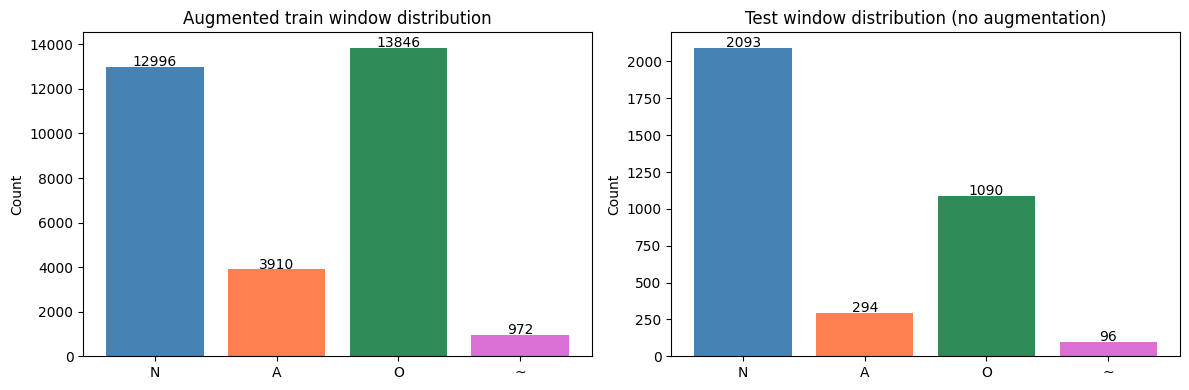

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_names = ["N", "A", "O", "~"]

train_counts = [np.sum(data["y_train_4class"] == i) for i in range(4)]
test_counts  = [np.sum(data["y_test"] == i)         for i in range(4)]

axes[0].bar(label_names, train_counts, color=["steelblue","coral","seagreen","orchid"])
axes[0].set_title("Augmented train window distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(train_counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

axes[1].bar(label_names, test_counts, color=["steelblue","coral","seagreen","orchid"])
axes[1].set_title("Test window distribution (no augmentation)")
axes[1].set_ylabel("Count")
for i, v in enumerate(test_counts):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("ECG_Hierarchical/class_distribution.png", dpi=100)
plt.show()

In [37]:
print("Phase 1 complete. Files in ECG_Hierarchical/:")
for fname in sorted(os.listdir("ECG_Hierarchical")):
    fpath = os.path.join("ECG_Hierarchical", fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f"  {fname:35s}  {size:8.2f} MB")

Phase 1 complete. Files in ECG_Hierarchical/:
  X_test_feat.npy                          0.56 MB
  X_test_sig.npy                          64.31 MB
  X_test_spec.dat                        468.32 MB
  X_train_feat.npy                         4.95 MB
  X_train_sig.npy                        571.03 MB
  X_train_spec.dat                      4158.13 MB
  aug_signals.dat                        571.03 MB
  class_distribution.png                   0.03 MB
  feat_cols.pkl                            0.00 MB
  memmap_shapes.pkl                        0.00 MB
  nonnormal_mask.npy                       0.03 MB
  scaler.pkl                               0.00 MB
  spectrogram_samples.png                  0.83 MB
  y_test.npy                               0.03 MB
  y_train_3class.npy                       0.15 MB
  y_train_4class.npy                       0.25 MB
  y_train_binary.npy                       0.25 MB
